## IRIS FLOWER CLASSIFICATION


# libraries:

In [40]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer


In [41]:
import warnings
warnings.filterwarnings("ignore")

#  Config / paths

In [42]:
CSV_PATH = "IRIS.csv"    
PROCESSED_PATH = "IRIS_processed.csv"


#  Load dataset

In [43]:
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"{CSV_PATH} not found. Put your IRIS.csv in the workspace or update CSV_PATH.")

df = pd.read_csv(CSV_PATH)
print("Loaded dataset shape:", df.shape)


Loaded dataset shape: (150, 5)


In [44]:
print("\n=== HEAD ===")
print(df.head())

print("\n=== INFO ===")
print(df.info())

print("\n=== DESCRIBE ===")
print(df.describe(include='all'))


=== HEAD ===
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

=== DESCRIBE ===
        sepal_length  sepal_width  petal_length  petal_width      species
coun

#  Column names check & normalization

In [45]:
print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())



=== COLUMN NAMES ===
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


# Normalize column names (optional) -> remove spaces, lowercase

In [46]:
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print("Normalized columns:", df.columns.tolist())


Normalized columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


#  Missing values check

In [47]:
print("\n=== MISSING VALUES (count by column) ===")
print(df.isnull().sum())


=== MISSING VALUES (count by column) ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


#  Percentage missing (helpful)

In [48]:
missing_pct = df.isnull().mean() * 100
print("\n=== MISSING VALUES (%) ===")
print(missing_pct)


=== MISSING VALUES (%) ===
sepal_length    0.0
sepal_width     0.0
petal_length    0.0
petal_width     0.0
species         0.0
dtype: float64


#  Duplicate rows check

In [49]:
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count}")
if dup_count > 0:
    print("Dropping duplicate rows...")
    df = df.drop_duplicates().reset_index(drop=True)
    print("New shape after dropping duplicates:", df.shape)



Duplicate rows: 3
Dropping duplicate rows...
New shape after dropping duplicates: (147, 5)


#  Data types & convert numeric columns if needed

In [50]:
print("\n=== DATA TYPES BEFORE ===")
print(df.dtypes)



=== DATA TYPES BEFORE ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


# Try to coerce numeric columns 

In [51]:
numeric_cols = []
for col in df.columns:
    # Heuristic: columns with 'length' or 'width' or numeric-like
    if any(sub in col for sub in ["length", "width", "sepal", "petal"]):
        numeric_cols.append(col)

print("Numeric-looking columns:", numeric_cols)


Numeric-looking columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


# Coerce numeric columns to float

In [52]:
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\n=== DATA TYPES AFTER coercion ===")
print(df.dtypes)



=== DATA TYPES AFTER coercion ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


#  Re-check missing values after coercion

In [53]:
print("\nMissing values after coercion:")
print(df.isnull().sum())



Missing values after coercion:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


# Find candidate label column (commonly 'species' or 'class' or last column)

In [54]:
possible_label_cols = [c for c in df.columns if c not in numeric_cols]
print("\nNon-numeric columns (candidates for label):", possible_label_cols)



Non-numeric columns (candidates for label): ['species']


In [55]:
label_col = None
for cand in ['species', 'class', 'target', 'label']:
    if cand in df.columns:
        label_col = cand
        break
if label_col is None:
    # fallback: last column
    label_col = df.columns[-1]
print("Using label column:", label_col)

Using label column: species


# Check label unique values

In [56]:
print("\nLabel value counts:")
print(df[label_col].value_counts())



Label value counts:
species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64


#  Encode labels to numeric if they are strings

In [57]:
if df[label_col].dtype == object or not np.issubdtype(df[label_col].dtype, np.number):
    print("\nLabel column is non-numeric -> encoding with LabelEncoder")
    le = LabelEncoder()
    df[label_col] = le.fit_transform(df[label_col].astype(str))
    # Save mapping for interpretability
    label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("Label mapping (string -> int):", label_mapping)
else:
    print("\nLabel column already numeric.")


Label column is non-numeric -> encoding with LabelEncoder
Label mapping (string -> int): {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


#  Final sanity checks before train/test split

In [58]:
print("\n=== FINAL DATAFRAME INFO ===")
print(df.info())
print("\nFinal head:")
print(df.head())


=== FINAL DATAFRAME INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 5.9 KB
None

Final head:
   sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


#  Feature / target split

In [59]:
X = df.drop(columns=[label_col])
y = df[label_col]

print("\nX shape:", X.shape, "y shape:", y.shape)


X shape: (147, 4) y shape: (147,)


# feature scaling

In [60]:
scale_features = True
if scale_features:
    print("\nApplying StandardScaler to numeric features...")
    scaler = StandardScaler()
    X_scaled = X.copy()


Applying StandardScaler to numeric features...


#  Train-test split

In [61]:
TEST_SIZE = 0.2
RANDOM_STATE = 42
print(f"\nSplitting data: test_size={TEST_SIZE}, random_state={RANDOM_STATE}")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())



Splitting data: test_size=0.2, random_state=42
X_train: (117, 4) X_test: (30, 4)
y_train distribution:
 species
1    40
2    39
0    38
Name: count, dtype: int64
y_test distribution:
 species
1    10
2    10
0    10
Name: count, dtype: int64


#  Save processed dataset 

In [62]:
print(f"\nSaving processed dataset to {PROCESSED_PATH}")
processed_df = pd.concat([X, y], axis=1)
processed_df.to_csv(PROCESSED_PATH, index=False)
print("Saved.")



Saving processed dataset to IRIS_processed.csv
Saved.


# train multiple model

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [64]:

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)
}

#  Create a DataFrame of model performance

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc * 100, 2), "%")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


=== Logistic Regression ===
Accuracy: 96.67 %
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

=== KNN ===
Accuracy: 100.0 %
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


# Feature Importance Visualization


=== Feature Importance ===
        Feature  Importance
2  petal_length    0.443075
3   petal_width    0.414662
0  sepal_length    0.121489
1   sepal_width    0.020774


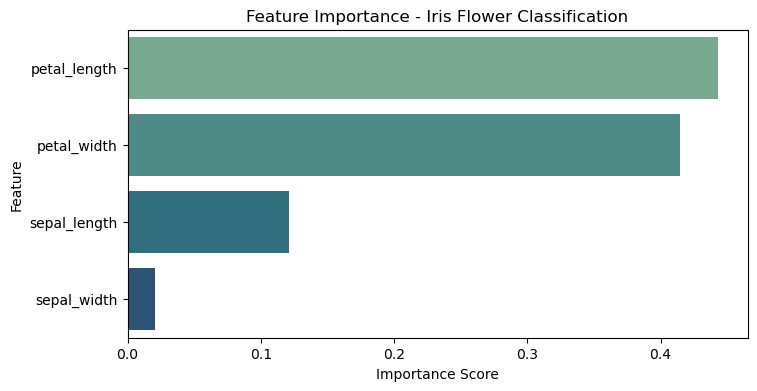

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Use Random Forest (best for feature importance visualization)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#  Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': df.columns[:-1],  # exclude 'species' column
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n=== Feature Importance ===")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='crest')
plt.title("Feature Importance - Iris Flower Classification")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [67]:
import pandas as pd

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

                 Model  Accuracy
1                  KNN  1.000000
0  Logistic Regression  0.966667
3        Random Forest  0.966667
2        Decision Tree  0.933333
4                  SVM  0.933333


# select the best model

In [68]:
best_model_name = results_df.iloc[0, 0]   # Gets model with highest accuracy
best_model = models[best_model_name]

print(f"Best model: {best_model_name}")

Best model: KNN


# save the model

In [69]:
import joblib

joblib.dump(best_model, "iris_best_model.pkl")
joblib.dump(scaler, "iris_scaler.pkl")

print(f"✅ Best model '{best_model_name}' saved as 'iris_best_model.pkl'")
print("✅ Scaler saved as 'iris_scaler.pkl'")

✅ Best model 'KNN' saved as 'iris_best_model.pkl'
✅ Scaler saved as 'iris_scaler.pkl'


# Load the Model and Scaler

In [70]:
import joblib
import numpy as np

# ✅ Load saved model and scaler
model = joblib.load("iris_best_model.pkl")
scaler = joblib.load("iris_scaler.pkl")

In [71]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load your dataset again
df = pd.read_csv("IRIS.csv")

# Split features and labels
X = df.drop(columns=["species"])
y = df["species"]

# Fit the scaler again on full data
scaler = StandardScaler()
scaler.fit(X)

# Save it again for future use
import joblib
joblib.dump(scaler, "iris_scaler.pkl")
print("✅ Scaler refitted and saved successfully!")

✅ Scaler refitted and saved successfully!


# prediction

In [72]:
import numpy as np
model = joblib.load("iris_best_model.pkl")
scaler = joblib.load("iris_scaler.pkl")

sample = np.array([[5.8, 2.7, 5.1, 1.9]])
sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)

In [73]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df["species"])
print("🌸 Predicted Iris Species:", le.inverse_transform(prediction)[0])

🌸 Predicted Iris Species: Iris-setosa
